In [40]:
import numpy as np
import pandas as pd
import os

IMAGE_DIR = '/Users/songbeom/PythonWorkSpace/CNN_project/data/plant_pathology_2020/images/'
test_df = pd.read_csv('../data/plant_pathology_2020/test.csv')
train_df = pd.read_csv('../data/plant_pathology_2020/train.csv')


In [5]:
train_df.head()

,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,0,1
1,Train_1,0,1,0,0
2,Train_2,1,0,0,0
3,Train_3,0,0,1,0
4,Train_4,1,0,0,0


In [6]:
test_df.head()

,image_id
0,Test_0
1,Test_1
2,Test_2
3,Test_3
4,Test_4


In [7]:
train_df.shape, test_df.shape

((1821, 5), (1821, 1))

#### 이미지의 절대 경로를 DataFrame에 추가하고 개별 컬럼별 0/1 값을 구분하여 클래스 라벨로 생성

In [8]:
train_df['path'] = '/Users/songbeom/PythonWorkSpace/CNN_project/data/plant_pathology_2020/images/' + train_df['image_id'] + '.jpg'

train_df['path'][0] # 이미지 절대 경로 만들어 주기

'/Users/songbeom/PythonWorkSpace/CNN_project/data/plant_pathology_2020/images/Train_0.jpg'

(1365, 2048, 3)


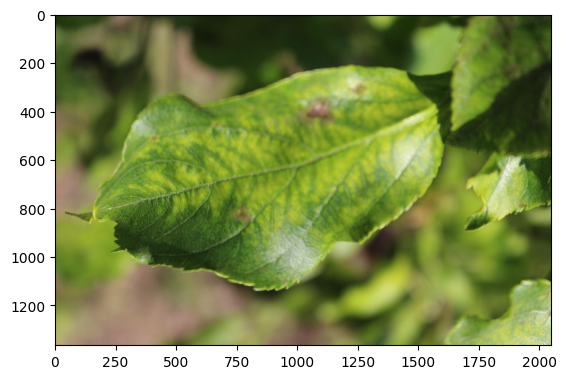

In [9]:
import cv2
import matplotlib.pyplot as plt

image = cv2.cvtColor(cv2.imread(train_df['path'][0]), cv2.COLOR_BGR2RGB)
print(image.shape)
plt.imshow(image)

In [10]:
train_df.head()

,image_id,healthy,multiple_diseases,rust,scab,path
0,Train_0,0,0,0,1,/Users/songbeom/PythonWorkSpace/CNN_project/da...
1,Train_1,0,1,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...
2,Train_2,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...
3,Train_3,0,0,1,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...
4,Train_4,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...


In [11]:
def get_label(x):
    if x['healthy'] == 1:
        return 'healthy'
    elif x['multiple_diseases'] == 1:
        return 'multiple_diseases'
    elif x['rust'] == 1:
        return 'rust'
    elif x['scab'] == 1:
        return 'scab'

train_df['label'] = train_df.apply(lambda x: get_label(x), axis=1)

train_df.head()

,image_id,healthy,multiple_diseases,rust,scab,path,label
0,Train_0,0,0,0,1,/Users/songbeom/PythonWorkSpace/CNN_project/da...,scab
1,Train_1,0,1,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,multiple_diseases
2,Train_2,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,healthy
3,Train_3,0,0,1,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,rust
4,Train_4,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,healthy


In [12]:
train_df['label'].value_counts()

label
rust                 622
scab                 592
healthy              516
multiple_diseases     91
Name: count, dtype: int64

In [13]:
# label 명을 target 값으로 매핑
label_mapping = {'healthy' : 0, 'multiple_diseases' : 1, 'rust': 2, 'scab' : 3}


train_df['target'] = train_df['label'].map(label_mapping)

In [14]:
train_df['target'].value_counts()

target
2    622
3    592
0    516
1     91
Name: count, dtype: int64

In [15]:
train_df.head()

,image_id,healthy,multiple_diseases,rust,scab,path,label,target
0,Train_0,0,0,0,1,/Users/songbeom/PythonWorkSpace/CNN_project/da...,scab,3
1,Train_1,0,1,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,multiple_diseases,1
2,Train_2,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,healthy,0
3,Train_3,0,0,1,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,rust,2
4,Train_4,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,healthy,0


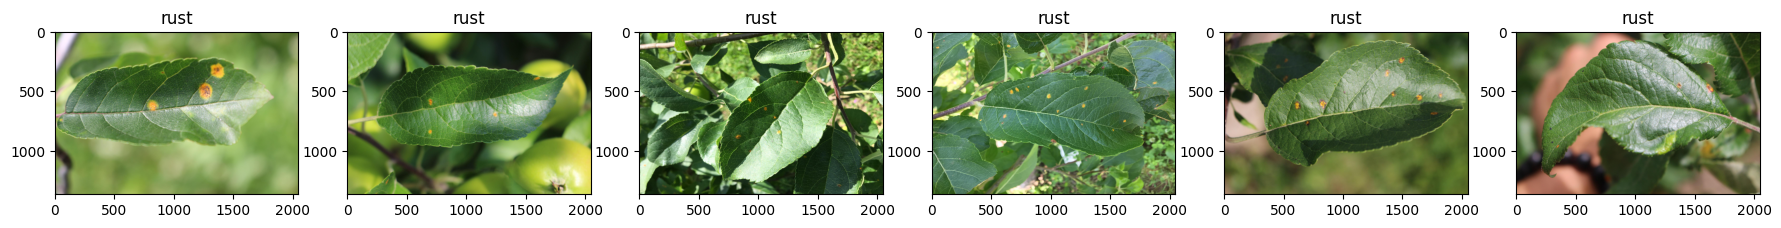

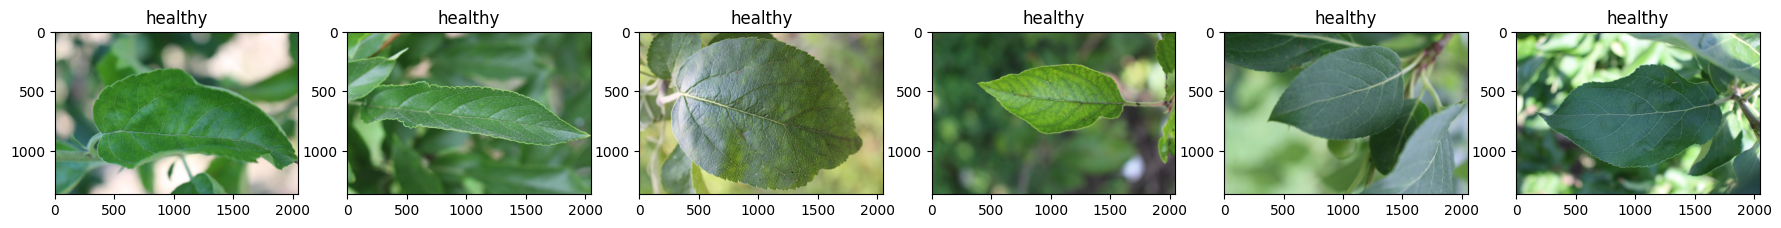

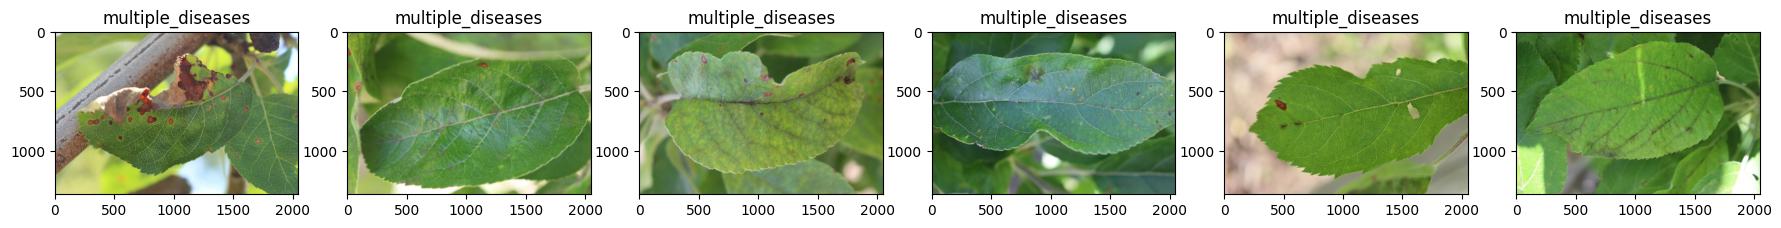

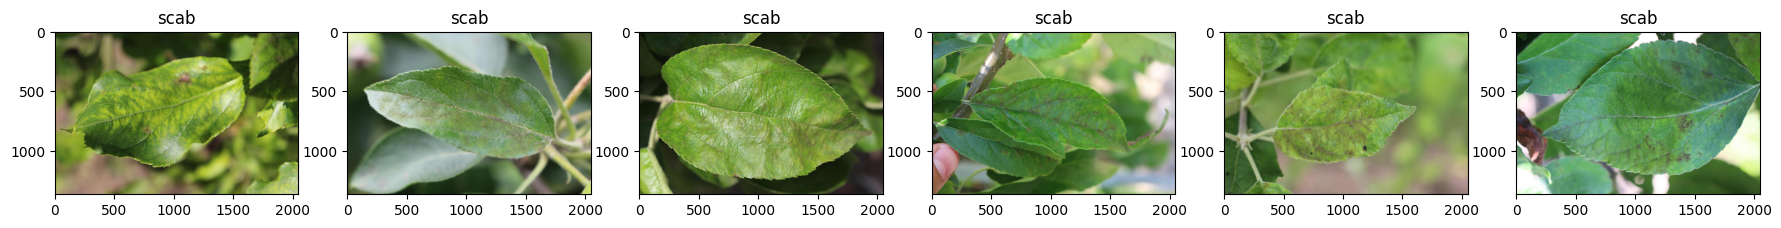

In [16]:
def show_grid_images(image_path_list, augmentor=None, ncols=4, title=None):
    figure, axs = plt.subplots(figsize=(22,4), nrows=1, ncols=ncols)
    for i in range(ncols):
        image = cv2.cvtColor(cv2.imread(image_path_list[i]), cv2.COLOR_BGR2RGB)
        if augmentor is not None:
            image = augmentor(image=image)['image']
        axs[i].imshow(image)
        axs[i].set_title(title)

# healthy' : 0, 'multiple_diseases' : 1, 'rust': 2, 'scab' : 3
rust_image_list = train_df[train_df['label'] == 'rust']['path'].iloc[:6].tolist()
healthy_image_list = train_df[train_df['label'] == 'healthy']['path'].iloc[:6].tolist()
multiple_diseases_image_list = train_df[train_df['label'] == 'multiple_diseases']['path'].iloc[:6].tolist()
scab_image_list = train_df[train_df['label'] == 'scab']['path'].iloc[:6].tolist()


show_grid_images(rust_image_list, ncols=6, title='rust')
show_grid_images(healthy_image_list, ncols=6, title='healthy')
show_grid_images(multiple_diseases_image_list, ncols=6, title='multiple_diseases')
show_grid_images(scab_image_list, ncols=6, title='scab')


#### 이미지 Augmentation을 적용
- cutout과 같은 noise는 나뭇잎의 병균 반점과 헷갈릴 수 있으므로 사용하지 않음
- 전체 이미지가 파란색 계열이고 병균 반점이 특정 색깔을 가지고 있으므로 색상의 변화는 적용하지 않음
- 전반적으로 판별하려는 나뭇잎이 전체 이미지의 중앙에 와있음. crop또는 scale등의 적용 고려

/Users/songbeom/PythonWorkSpace/CNN_project/.venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


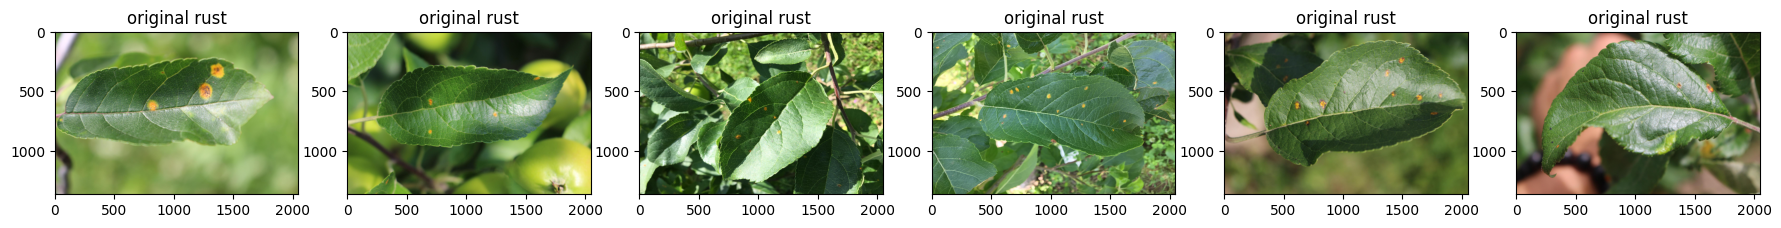

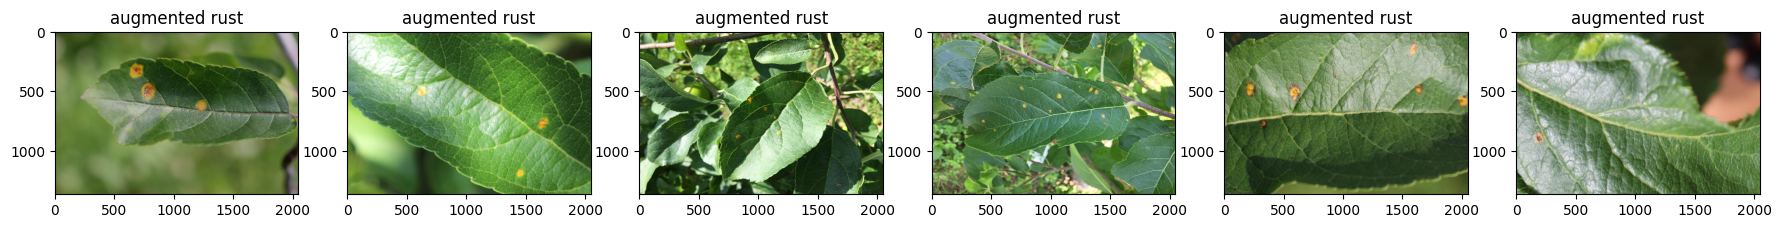

In [23]:
import albumentations as A

augmentor_01 = A.Compose([
    A.HorizontalFlip(p=0.3), # 좌우반전
    A.VerticalFlip(p=0.3), # 상하반전
    A.ShiftScaleRotate(scale_limit=(0.7, 0.9), rotate_limit=30), # scale_limit 이미지가 70~90%로 축소되고, rotate_limit -30~30도 범위에서 회전 
    A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), p=0.3) # 밝기/대비 조절 +-20
])


show_grid_images(rust_image_list, ncols=6, title='original rust')
show_grid_images(rust_image_list, augmentor=augmentor_01, ncols=6, title='augmented rust')


#### Custom Dataset과 DataLoader를 활용하여 모델 학습에 필요한 데이터셋 구성
- Kaggle의 테스트용 Dataset은 target값이 없으므르 image 배치만 반환할 수 있도록 적용 필요
- 처음에는 학습 데이터를 다시 학습과 검증용 Dataset으로 분리하지만, 추후에는 검증용 데이터를 사용하지 않고 모두 학습용 데이터로 사용

In [25]:
from sklearn.model_selection import train_test_split


tr_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['target'], random_state=2026)

tr_df.shape, val_df.shape

((1547, 8), (274, 8))

In [27]:
val_df['label'].value_counts()

label
rust                 93
scab                 89
healthy              78
multiple_diseases    14
Name: count, dtype: int64

In [30]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image

class PlantDataset(Dataset):
    # 이미지 파일리스트, 타켓 파일리스트, transforms 등 이미지와 타켓 데이터 가공에 필요한 인자들을 입력 받음
    def __init__(self, image_paths, targets=None, transform=None):
        self.image_paths = image_paths
        self.targets = targets
        self.transform = transform
    
    # 전체 건수를 반환
    def __len__(self):
        return len(self.image_paths)
    
    # idx로 지정된 하나의 image, label을 tensor 형태로 반환
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        # cv2로 image 로딩.
        image_np = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB).astype(np.float32)
        # 보통은 transform이 None이 되는 경우는 거의 없음(Tensor 변환이라도 있음)
        image = self.transform(image=image_np)['image']
        
        if self.targets is not None:
            # 개별 target값은 tensor로 변환
            target = torch.tensor(self.targets[idx])
            return image, target
        # 테스트 데이터의 경우 targets가 입력 되지 않을 수 있으므로
        else:
            # return image, None이 아니라 image만 반환, default collate_fn()는 None을 입력 받으면 오류 발생
            return image

In [39]:
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

class CFG:
    batch_size = 16
    image_size = 240
    image_mean = (0.485, 0.456, 0.406) # ImageNet 데이터세트의 이미지 채널별 평균값
    image_std = (0.229, 0.224, 0.225) # ImageNet 데이터세트의 이미지 채널별 표준편차값
    
# 이미지가 크므로 HorizontalFlip 적용 전 Resize를 먼저 적용하여 이미지를 작게 만든 뒤 적용(모델 성능이 살짝 떨어질 수 있음) 
tr_transform_01 = A.Compose([
    A.Resize(CFG.batch_size, CFG.image_size, p=1),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=CFG.image_mean, std=CFG.image_std),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(CFG.batch_size, CFG.image_size, p=1),
    A.Normalize(mean=CFG.image_mean, std=CFG.image_std),
    ToTensorV2()
])


def create_tr_val_loader(tr_df, val_df, tr_transform, val_transform):
    tr_dataset = PlantDataset(image_paths=tr_df['path'].to_list(),
                              targets=tr_df['target'].to_list(), transform=tr_transform)
    tr_loader = DataLoader(tr_dataset, batch_size=CFG.batch_size, shuffle=True)
    # 추후에 validation용 Dataset를 만들지 않고, 기존 검증용 이미지를 학습용 이미지로 다 사용할 수 있음
    if val_df is not None:
        val_dataset = PlantDataset(image_paths=val_df['path'].to_list(),
                              targets=val_df['target'].to_list(), transform=val_transform)
        val_loader = DataLoader(val_dataset, batch_size=4*CFG.batch_size, shuffle=False)

        return tr_loader, val_loader

    return tr_loader, None

tr_loader, val_loader = create_tr_val_loader(tr_df, val_df, tr_transform_01, val_transform)

images, labels = next(iter(tr_loader))

print(image.shape, labels.shape)


(1365, 2048, 3) torch.Size([16])


In [35]:
tr_loader, val_loader = create_tr_val_loader(tr_df, None, tr_transform_01, None)

images, labels = next(iter(tr_loader))

print(image.shape, labels.shape, val_loader)

(1365, 2048, 3) torch.Size([16]) None


In [46]:
test_df['path'] = IMAGE_DIR + test_df['image_id'] + '.jpg'
test_df['path'][0]

'/Users/songbeom/PythonWorkSpace/CNN_project/data/plant_pathology_2020/images/Test_0.jpg'

In [ ]:
test_image_paths = test_df['path'].to_list()

test_transform = A.Compose([
    A.Resize(CFG.batch_size, CFG.image_size, p=1),
    A.Normalize(mean=CFG.image_mean, std=CFG.image_std),
    ToTensorV2()
])

# test용 Dataset은 targets가 입력되지 않음.
test_dataset = PlantDataset(image_paths=test_image_paths,
                            targets=None, transform=test_transform)

test_loader = DataLoader(test_dataset, batch_size=4*CFG.batch_size, shuffle=False, num_workers=0, pin_memory=False)

# test_loader는 batch단위 image들만 반환, target값 반환은 없음
images = next(iter(test_loader))

print(image.shape)

(1365, 2048, 3)


#### torchvision의 EfficientNet 계열 모델 생성

In [61]:
from torchvision import models

models.list_models(include='efficientnet*')

['efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s']

In [62]:
models.efficientnet_b1(weights='DEFAULT')

0.4%

Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /Users/songbeom/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100.0%


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [81]:
import torch
import torch.nn as nn
from torchvision import models


def create_tv_model(model_name: str, num_classes: int=1000, weights: str='DEFAULT') -> models:
    model = None
    if model_name == 'efficientnet_b1':
        model = models.efficientnet_b1(weights=weights)
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(in_features=1280, out_features=num_classes)
        )
    
    return model

#### Trainer 클래스로 학습하기 - torchmetrics를 이용하여 ROC-AUC 계산
- 기존 정확도를 구하는 로직을 torchmetrics의 AUROC 클래스를 이용하여 ROC-AUC 계산하도록 변경
- AUROC는 예측 입력 값으로 예측 확률값을 입력 받아야 함(model의 출력 결과에 F.softmax 적용 필요)

In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import os
from typing import Optional

class TrainerWithTM:
    def __init__(self, model: nn.Module, loss_fn, optimizer: torch.optim.Optimizer, train_loader: DataLoader, val_loader: Optional[DataLoader], 
                scheduler=None, callbacks=None, metric=None, device=None):
        self.model = model.to(device)
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.scheduler = scheduler
        # 현재 learning rate 변수 추가
        self.current_lr = self.optimizer.param_groups[0]['lr']
        # checkpoint와 early stopping 클래스들을 list로 받음.
        self.callbacks = callbacks
        # torchmetrics 객체 입력 받음
        self.metric = metric.to(device)
    
    def train_epoch(self, epoch: int):
        self.model.train()
        
        # running  평균 loss 계산
        accu_loss = 0.0
        running_avg_loss = 0.0
        # metric 초기화
        self.metric.reset()
        # tqdm으로 실시간 training loop 진행 상황 시각화
        with tqdm(total=len(self.train_loader), desc=f'Epoch {epoch+1} [Training..]', leave=True) as progress_bar:
            for batch_idx, (inputs, targets) in enumerate(self.train_loader, start=1):
                inputs = inputs.to(self.device)
                targets = targets.to(self.device)
                
                # Forward pass
                outputs = self.model(inputs)
                loss = self.loss_fn(outputs, targets)
                
                # Backward pass
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                
                # batch 반복 시 마다 누적 loss를 구하고 batch 횟수로 나눠서 running 평균 loss 수행
                accu_loss += loss.item()
                running_avg_loss = accu_loss / batch_idx
                
                # torchmetrics의 AUROC 클래스는 pred 예측 값으로 예측 확률값이 입력되어야 함.
                pred_proba = F.softmax(outputs, dim=-1) # 0 ~ 1 사이의 확률로 계산
                self.metric.update(pred_proba, targets)
                
                # tqdm progress_bar에 진행 상황 및 running 평균 loss와 정확도 표시
                progress_bar.update(1)
                if batch_idx % 20 == 0 or batch_idx == progress_bar.total: # 20 batch 횟수마다 또는 맨 마지막 batch에서
                    progress_bar.set_postfix({
                        "Loss" : running_avg_loss,
                        "AUC" : self.metric.compute().item()
                    })
                    
        # 스케줄러가 ReduceLROnPlateau 아닐 때만 scheduler 업데이트 -> validation에서만 작동함
        if (self.scheduler is not None) and (not isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau)):
            self.scheduler.step()
            self.current_lr = self.scheduler.get_last_lr()[0]
        
        return running_avg_loss, self.metric.compute().item()
    
    
    def validation_epoch(self, epoch):
        if not self.val_loader:
            return None, None
        
        self.model.eval()
        
        # running 평균 loss 계산
        accu_loss = 0.0
        running_avg_loss = 0.0
        current_lr = self.optimizer.param_groups[0]['lr']
        
        # metric 초기화
        self.metric.reset()
        
        with tqdm(total=len(self.val_loader), desc=f'Epoch {epoch+1} [Validating]', leave=True) as progress_bar:
            with torch.no_grad():
                for batch_idx, (images, targets) in enumerate(self.val_loader, start=1):
                    images = images.to(self.device)
                    targets = targets.to(self.device)
                    
                    outputs = self.model(images)
                    
                    loss = self.loss_fn(outputs, targets)
                    
                    accu_loss+= loss.item()
                    running_avg_loss = accu_loss / batch_idx
                    
                    pred_proba = F.softmax(outputs, dim=-1)
                    self.metric.update(pred_proba, targets)
                    
                    # tqdm process_bar에 진행 상황 및 running 평균 loss의 정확도 표시
                    progress_bar.update(1)
                    if batch_idx == 20 or batch_idx == progress_bar.total:
                        progress_bar.set_postfix({
                            "Loss" : running_avg_loss,
                            "AUC" : self.metric.compute().item()
                        })
        
        if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            self.scheduler(running_avg_loss)
            self.current_lr = self.scheduler.get_last_lr()[0]
            
        return running_avg_loss, self.metric.compute().item()             
        
    def fit(self, epochs):
        # epoch 시마다 학습/검증 결과를 기록하는 history dict 생성
        history = {
                   'train_loss' : [],
                   'train_metric' : [],
                   'val_loss' : [],
                   'val_metric' : [],
                   'lr' : []
                   }
        for epoch in range(epochs):
            train_loss, train_metric = self.train_epoch(epoch)
            val_loss, val_metric = self.validation_epoch(epoch)
            print(f"Epoch {epoch+1}/{epochs}, Train Loss : {train_loss:.4f} Train Auc: {train_metric:.4f}",
                  f", Val Loss: {val_loss:.4f} Val Auc: {val_metric:.4f}" if val_loss is not None else "",
                  f", Current lr: {self.current_lr:.6f}")
            history['train_loss'].append(train_loss)
            history['train_metric'].append(train_metric)
            history['val_loss'].append(val_loss)
            history['val_metric'].append(val_metric)
            history['lr'].append(self.current_lr)

            # 
            if self.callbacks:
                is_epoch_loop_break = self._execute_callbacks(self.callbacks, self.model, epoch, val_loss, val_metric)
                if is_epoch_loop_break:
                    break
        
        return history
            
    # 생성 인자로 들어온 callbacks list을 하나씩 꺼내서 ModelCheckpoint, EarlyStopping을 수행.
    # EarlyStopping 호출 시 early stop 여부를 판단하는 is_early_stopped 반환
    def _execute_callbacks(self, callbacks, model, epoch, val_loss, val_metric):
        is_early_stopped = False
        
        for callback in self.callbacks:
            if isinstance(callback, ModelCheckpoint):
                if callback.monitor == 'val_loss':
                    callback.save(model, epoch, val_loss)
                elif callback.monitor == 'val_metric':
                    callback.save(model, epoch, val_metric)
            if isinstance(callback, EarlyStopping):
                if callback.monitor == 'val_loss':
                    is_early_stopped = callback.check_early_stop(val_loss)
                elif callback.monitor == 'val_metric':
                    is_early_stopped = callback.check_early_stop(val_metric)
                    
        return is_early_stopped
    
    # 학습이 완료된 모델 반환
    def get_trained_model(self):
        return self.model

In [84]:
eff_b1_model = create_tv_model('efficientnet_b1', num_classes=4)

In [86]:
from torchmetrics.classification import AUROC

# ROC-AUC 측정을 위한 AUROC 객체 생성
auc_metric = AUROC(task='multiclass', num_classes=4)